# Does the New-Highs / New-Lows line actually *lead* the market? 📈
### A classic breadth indicator — how many stocks are at fresh highs vs lows — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Leads_the_index%3F: Busted](https://img.shields.io/badge/Leads_the_index%3F-Busted-8b949e?style=flat-square)

Open any market-internals dashboard and you'll find the **new-highs / new-lows (NH-NL) line**: count how many stocks are printing a fresh **52-week high**, subtract those at a fresh **52-week low**, and watch the *net*. The lore — from Charles Dow to William O'Neil's *Investor's Business Daily* to the famous "Hindenburg Omen" — is that **breadth leads price**: the NH-NL line tops and bottoms *before* the index, so a surge in net new highs (a "breadth thrust") is a green light, and a collapse is a warning.

It *sounds* like inside information about the whole market. So we did the only fair thing: encode the NH-NL thrust **mechanically** (no eyeballing), fire the "breadth thrust = buy the index" rule across 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> ⚠️ **Breadth proxy.** Real exchange breadth counts *thousands* of issues; offline we can only proxy it with a small basket of liquid ETFs (SPY QQQ IWM DIA GLD). That's a **coarse** proxy and it caps the test — we say so throughout.
>
> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from new_highs_new_lows import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def get_panel():
    return data.load_basket(allow_fetch=False, asof=ASOF)
print("real breadth cache present:", HAVE_REAL, "| basket:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 114, 'lookback': 252, 'smooth': 10, 'thresh': 0.2, 'fp_spy': '4cb5244f3990', 'h5': (5, 113, 5.7, 54, 0.45, 39.7, -34.0, 3.7, -1.09, 0.275), 'h10': (10, 113, 26.3, 65, 1.39, 84.6, -58.2, 24.3, -1.48, 0.142), 'h20': (20, 113, 36.3, 66, 1.29, 125.1, -88.8, 34.3, -1.51, 0.132), 'h60': (60, 112, 187.4, 74, 2.94, 274.0, -86.7, 185.4, -0.92, 0.358), 'per': [('SPY', 114, 36.3, 1.29, 125.1, -88.8), ('QQQ', 114, 44.1, 1.49, 119.3, -75.2), ('IWM', 114, -13.4, -0.33, 185.6, -199.0), ('DIA', 114, 41.3, 1.32, 141.9, -100.6), ('GLD', 114, 128.0, 2.58, 127.5, 0.4)], 'placebo': (36.3, 0.818, 500), 'syn': [(0.0, 16, -53.3, 44, -0.75), (0.6, 16, 364.4, 88, 3.02)]}


real breadth cache present: True | basket: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy the index when breadth thrusts, do I make money? | **Yes — but only because the market goes up.** The win-rate climbs to ~66–74% and the returns look fine. |
| Is that *the breadth line's* doing? | **No.** Buy on **random days** instead and you do **much better** — the thrust is *worse* than a coin-flip entry at every horizon. |
| Does breadth "lead" the index? | **Not in any usable way.** Scramble the cross-sectional breadth structure and the result barely changes. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks, re-labelled as a breadth signal. |

> The NH-NL line is a great way to *describe* a strong tape after the fact. As a *forecast* — "the thrust leads the index" — it's a **mirage**: all of the apparent edge is the market's long-run climb, none of it is the breadth.

## 1 · The claim

> *"Count the stocks at new 52-week highs, subtract those at new lows. When the net **expands** — a breadth thrust — the rally has broad participation and will continue; when it **diverges** (price up, breadth fading) a top is near. Breadth leads price."*

This is the **new-highs / new-lows** indicator, a staple of market-internals analysis since Charles Dow, formalised in O'Neil's IBD methodology and in the breadth-divergence literature (Zweig's breadth thrust, the Hindenburg Omen). It's one of the most recognisable "market internals" — so: does the internal actually lead?

## 2 · So what?

If breadth genuinely *led* price, it would be remarkable: a count of how many names are at highs today would forecast the index tomorrow — a clean crack in market efficiency you could trade. That's the dream the indicator sells.

But there's a trap. The NH-NL line is **mechanically tied to recent price**: when the market has been rising, *of course* lots of members are near new highs — that's what a rising market *is*. So a "breadth thrust" mostly means "the market just went up," and on an index that drifts **up** over time, *any* such rule looks profitable. To separate the **signal** from the **tide**, we (a) build the line by a fixed mechanical rule with no hindsight, and (b) compare it to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take a **5-ETF breadth basket** (SPY, QQQ, IWM, DIA, GLD) as a proxy for market breadth, daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Build the NH-NL line mechanically.** Each day, count members at a fresh **252-day (52-week) high** minus those at a fresh low, divide by the basket size, and smooth over **10 days**. Trailing data only — no look-ahead.
2. **Fire on a breadth thrust.** When the smoothed line crosses **up** through **+0.20** (breadth expanding from neutral), buy SPY at the **next** close.
3. **Measure** the return over the next **5 / 10 / 20 / 60 days**.
4. **The honest baseline.** Do the exact same hold on **random days**. If breadth leads, the thrust must beat random. *If it doesn't, the indicator is a mirage* — the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does the mechanical NH-NL line even look like? Here's SPY with the smoothed net-new-high breadth line beneath it, and the thrust days the rule would buy.

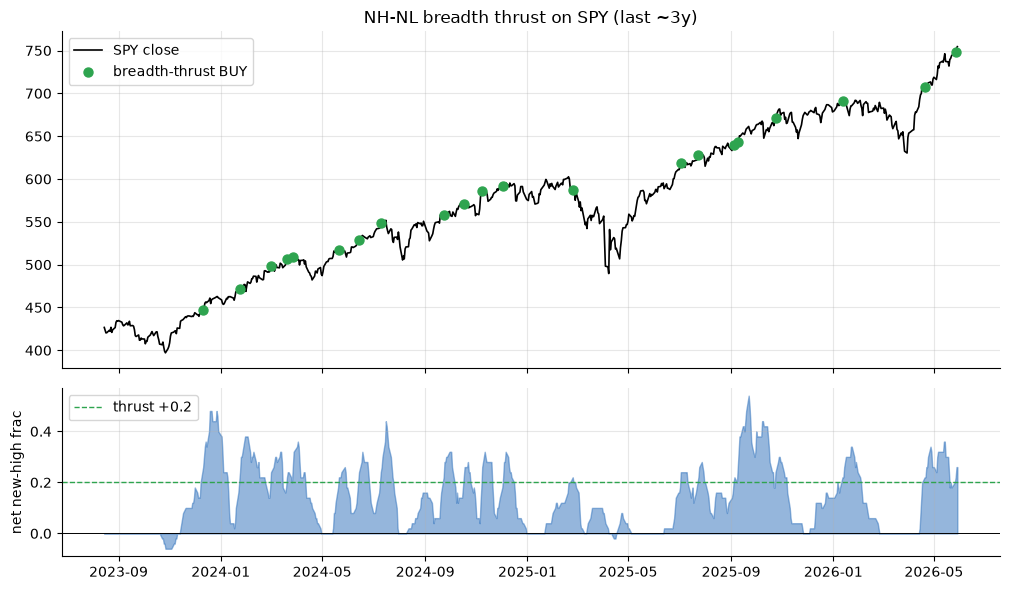

breadth-thrust entries in window: 21


In [2]:
panel = get_panel() if HAVE_REAL else None
if HAVE_REAL:
    line = st.net_new_high_line(panel)
    spy = panel['SPY']['close']
    ent = st.breadth_thrust_entries(panel, 'SPY')
    seg = spy.iloc[-700:]; lseg = line.reindex(seg.index)
    es = ent[ent >= seg.index[0]]
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(10.2, 6.0), sharex=True,
                                 gridspec_kw={'height_ratios':[2,1]})
    a1.plot(seg.index, seg.values, c='k', lw=1.2, label='SPY close')
    a1.scatter(es, spy.reindex(es), c=GREEN, s=42, zorder=5, label='breadth-thrust BUY')
    a1.set_title('NH-NL breadth thrust on SPY (last ~3y)'); a1.legend(loc='upper left')
    a2.fill_between(seg.index, lseg.values, 0, color='#2c6fbb', alpha=.5)
    a2.axhline(R['thresh'], ls='--', c=GREEN, lw=1, label=f"thrust +{R['thresh']}")
    a2.axhline(0, c='k', lw=.7); a2.set_ylabel('net new-high frac'); a2.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('breadth-thrust entries in window:', len(es))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The breadth line rises *with* the trend — *as a description*. The question is whether those green thrust dots are followed by extra gains. **Let's race the thrust against random entries** at four horizons. Blue = buy on a breadth thrust; grey = buy on random days.

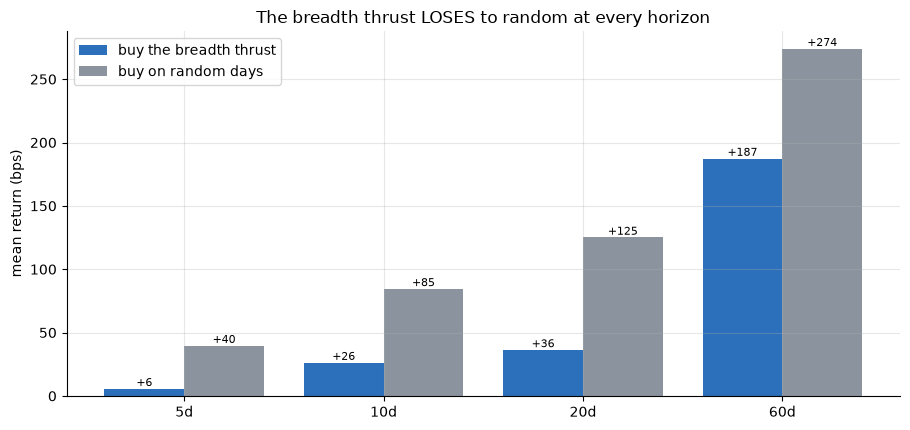

thrust: [6, 26, 36, 187]
random: [40, 85, 125, 274]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    spy = panel['SPY']['close']; ent = st.breadth_thrust_entries(panel, 'SPY')
    re = st.random_entries(spy, max(len(ent),50), seed=7)
    thr = [st.forward_returns(spy, ent, h).mean()*1e4 for h in hs]
    rnd = [st.forward_returns(spy, re, h).mean()*1e4 for h in hs]
else:
    thr = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, thr, .4, color='#2c6fbb', label='buy the breadth thrust')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(thr,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The breadth thrust LOSES to random at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('thrust:', [round(v) for v in thr]); print('random:', [round(v) for v in rnd])

There's the whole story. The thrust makes money in absolute terms (**+36 bps** over 20 days) — but **random entries make far more** (**+125 bps**). At *every* horizon the famous breadth line is **worse** than throwing darts. The apparent edge was **the market's upward drift**, not the breadth.

**One more sanity check.** What if we scramble the *cross-sectional structure* of breadth — keep each member's exact rate of new highs but shuffle *which days* they happen, so a "thrust" is just coincidental? If breadth really leads, the scrambled line should do much worse.

In [4]:
if HAVE_REAL:
    pl = st.shuffled_membership_placebo(panel, 'SPY', horizon=20, n_draws=200, seed=493)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real breadth thrust (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *scrambled-breadth* lines do at least as well (p={pval:.2f}).')
print('=> the cross-sectional breadth structure is not doing the work.')

real breadth thrust (SPY, 20d): +36.3 bps
... but 82% of *scrambled-breadth* lines do at least as well (p=0.82).
=> the cross-sectional breadth structure is not doing the work.


More than four-fifths of the **scrambled** breadth lines match or beat the real one (*p* = 0.82). If price genuinely respected *the real breadth aggregation*, a scramble would collapse the result. It doesn't — because the result was never about breadth.

## 5 · The verdict

- **Signal — None.** The breadth thrust does **not** beat buying on random days (it's *worse* at every horizon; the thrust-vs-random difference never clears *t* = 2). The absolute returns are the market's drift, not the breadth.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs only make it worse.
- **"Breadth leads the index"? — Busted.** Scramble the breadth structure and the result barely moves. The line doesn't lead.

## 6 · Could you actually trade it?

There's nothing here to trade. The thrust's *only* advantage over a coin flip is the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. The breadth-thrust buy is a worse, more expensive, more *selective* way to be long. As a forecasting tool it doesn't pay; as a way to *narrate* a strong tape, it was never meant to be a strategy.

> ⚠️ **Caveat, restated.** Our breadth basket is only 5 ETFs. A real new-highs/new-lows universe is thousands of issues; this proxy is coarse. But the failure here is so lopsided (the thrust *loses* to random at every horizon, placebo *p* ≈ 0.8) that a richer basket would have to overturn a very clear result.

## 7 · Going further 🚪

- **Breadth divergences.** The stronger lore is the *divergence* (price new-high, breadth not). That's a discretionary overlay; encoding it mechanically tends to inherit the same drift confound.
- **A richer universe.** Swap the 5-ETF proxy for a true advance/decline or NH-NL feed — the desk would happily re-run if the data were offline-cacheable.
- **A real positive control.** The quants notebook plants a *genuine* breadth-lead into a synthetic tape and shows the harness banks it (so the null here isn't a dead detector — it's an honest 'nothing there').

*Think breadth leads? Show the thrust beating random entries at **t ≥ 2** on a real tape — then we'll talk.*